#📌 Extracão

In [ ]:
import pandas as pd
import requests

In [ ]:
url='https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformação

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0.0)

In [ ]:
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


verificação  valores unicos


In [ ]:
for col in df.columns:
  print(col)
  print(df[col].unique())
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-'*50)

customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn
['No' 'Yes' '']
['No' 'Yes' '']
--------------------------------------------------
customer.gender
['Female' 'Male']
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen
[0 1]
[0 1]
--------------------------------------------------
customer.Partner
['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.Dependents
['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
customer.tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService
['Yes' 'No']
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines
['No' 'Yes' 'No phone service']
['No' 'Yes' 'No phone service']
---------------

2.valores duplicados


In [ ]:
df.duplicated().sum()

np.int64(0)

3.valores nulos


In [ ]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


4.valors vazios ou  em branco


In [ ]:
df.apply(lambda x: x.astype(str).str.strip()=='').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [ ]:
#removendo  os valores 'churn' vazios
df= df[df['Churn'].str.strip() != '']

In [ ]:
df.apply(lambda x: x.astype(str).str.strip()=='').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [ ]:
df = df.dropna(subset=['account.Charges.Total'])

In [ ]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


Diário Opcional

In [ ]:
df['contas_diarias'] = df['account.Charges.Monthly'] / 30
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


Padronização

In [ ]:

colunas = { # Dicionário com os novos nomes das colunas.
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem +60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'
}
df = df.rename(columns= colunas)
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [ ]:
df['Churn'] = df['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df['possui_parceiro'] = df['possui_parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df['possui_dependentes'] = df['possui_dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df['servico_telefone'] = df['servico_telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df['tipo_internet'] = df['tipo_internet'].replace({'No': 'Não'})
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [ ]:
columns_to_translate = ['seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes']
mapping = {'No': 'Não', 'Yes': 'Sim', 'No internet service': 'Sem serviço de internet'}
for col in columns_to_translate:
    df[col] = df[col].replace(mapping)

In [ ]:
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensal', 'Two year': 'Bienal'})

In [ ]:
df['fatura_digital'] = df['fatura_digital'].replace({'Yes': 'Sim', 'No': 'Não'})

In [ ]:
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'
})

In [ ]:
df

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,0,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7263,9992-RRAMN,Sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7264,9992-UJOEL,Não,Masculino,0,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7265,9993-LHIEB,Não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


#📊 Carga e análise

1.Analise Descritiva

In [ ]:
df.describe()

,tem +60,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158723
std,0.368612,24.559481,30.090047,2266.794470,1.003002
min,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,9.000000,35.500000,398.550000,1.183333
50%,0.000000,29.000000,70.350000,1394.550000,2.345000
75%,0.000000,55.000000,89.850000,3786.600000,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.958333


Distribuição de Evasão

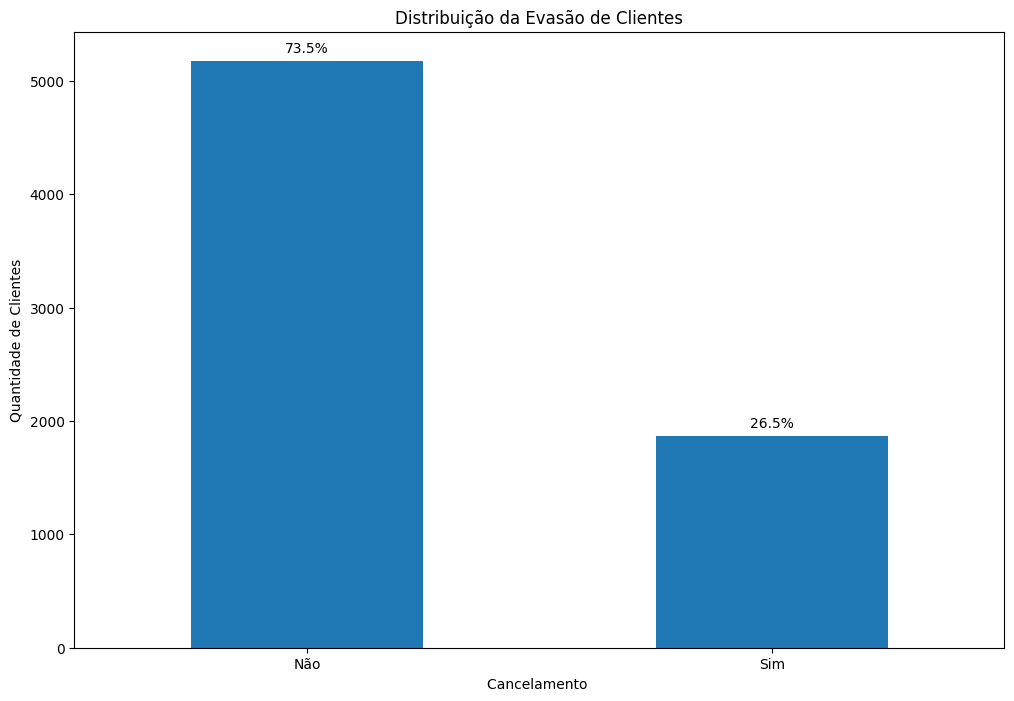

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')
plt.title('Distribuição da Evasão de Clientes')
plt.xlabel('Cancelamento ')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)

for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

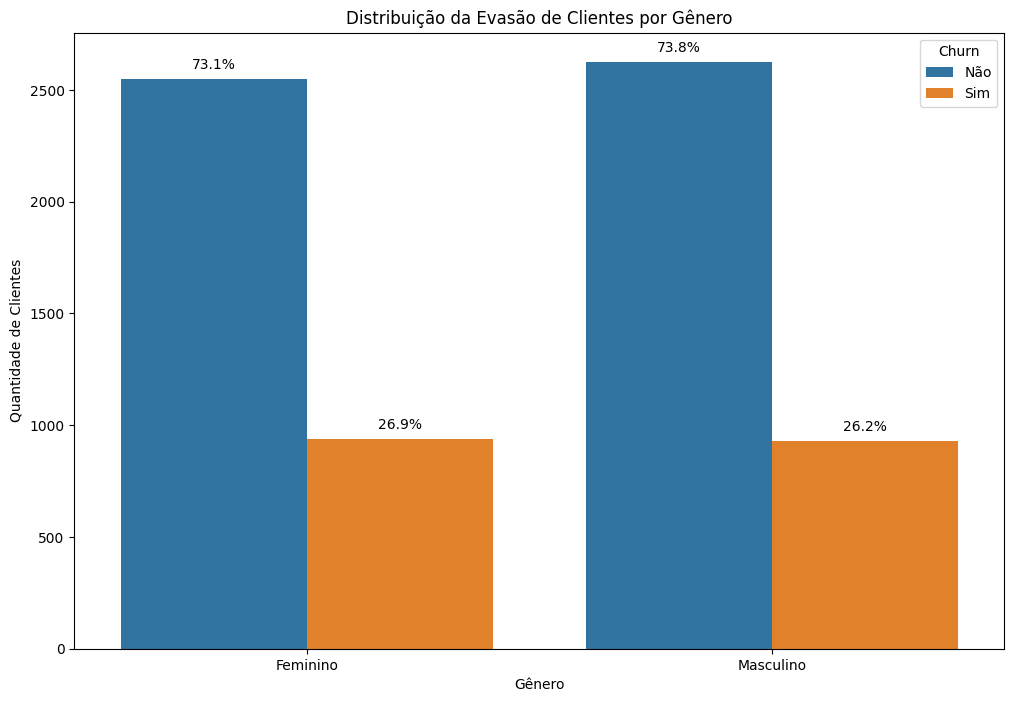

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df, x='genero', hue='Churn')
plt.title('Distribuição da Evasão de Clientes por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)

# Calculate percentages for each bar
total_gender_counts = df['genero'].value_counts()

for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid division by zero for empty bars
        gender = p.get_x() + p.get_width() / 2 # X-coordinate for the bar center
        # Find the gender label for the current bar
        if p.get_x() < 0.5: # Assuming 'Feminino' is the first group
            current_gender = 'Feminino'
        else:
            current_gender = 'Masculino'

        total = total_gender_counts[current_gender]
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()

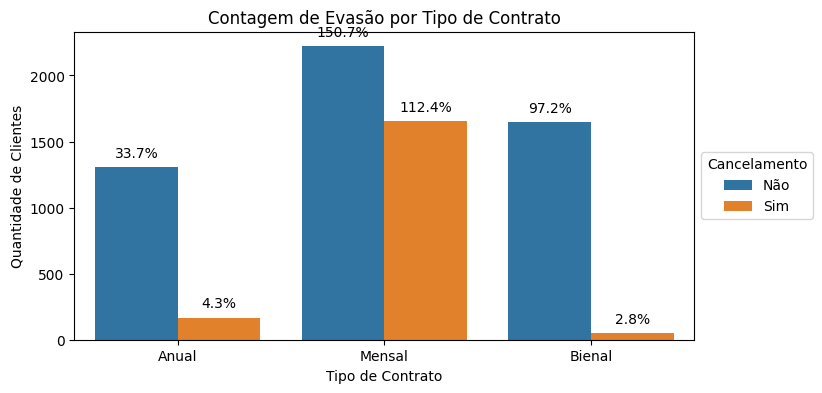

In [ ]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x='tipo_contrato', hue='Churn', data=df)
plt.title('Contagem de Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Cancelamento', labels=['Não', 'Sim'],
           loc='center left', bbox_to_anchor=(1, 0.5))

# Calculate percentages for each bar
total_contract_counts = df.groupby('tipo_contrato')['Churn'].count()

for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid division by zero for empty bars
        # Get the x-coordinate to determine the contract type and churn status
        x_coord = p.get_x() + p.get_width() / 2
        if x_coord < 0.5: # First group (Month-to-month by legend order or inspection)
            contract_type = 'Mensal'
        elif x_coord < 1.5: # Second group
            contract_type = 'Anual'
        else: # Third group
            contract_type = 'Bienal'

        total = total_contract_counts[contract_type]
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()

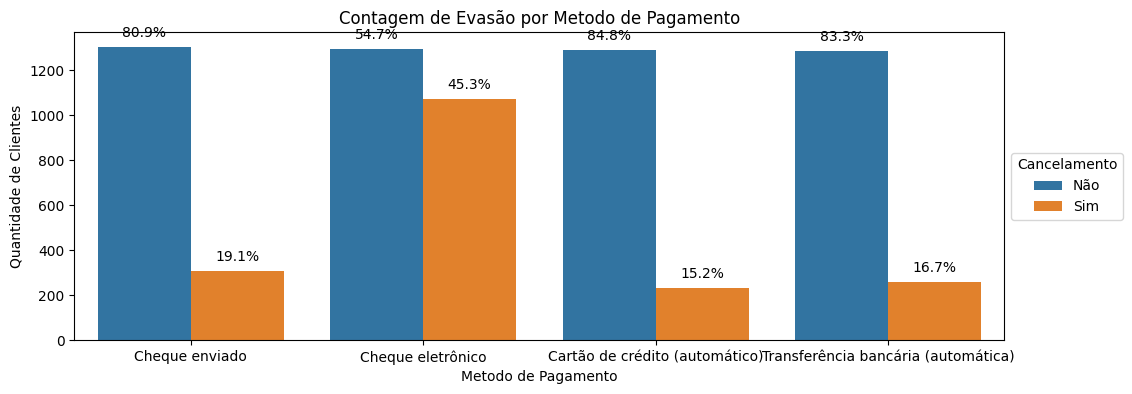

In [ ]:
plt.figure(figsize=(12, 4))
ax = sns.countplot(x='metodo_pagamento', hue='Churn', data=df)
plt.title('Contagem de Evasão por Metodo de Pagamento')
plt.xlabel('Metodo de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Cancelamento', labels=['Não', 'Sim'],
           loc='center left', bbox_to_anchor=(1, 0.5))

# Calculate percentages for each bar
total_payment_method_counts = df.groupby('metodo_pagamento')['Churn'].count()

for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid division by zero for empty bars
        # Get the x-coordinate to determine the payment method and churn status
        x_coord = p.get_x() + p.get_width() / 2
        # Determine the payment method based on x_coord
        if x_coord < 0.5:
            current_payment_method = 'Cheque enviado'
        elif x_coord < 1.5:
            current_payment_method = 'Cheque eletrônico'
        elif x_coord < 2.5:
            current_payment_method = 'Cartão de crédito (automático)'
        else:
            current_payment_method = 'Transferência bancária (automática)'

        total = total_payment_method_counts[current_payment_method]
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()

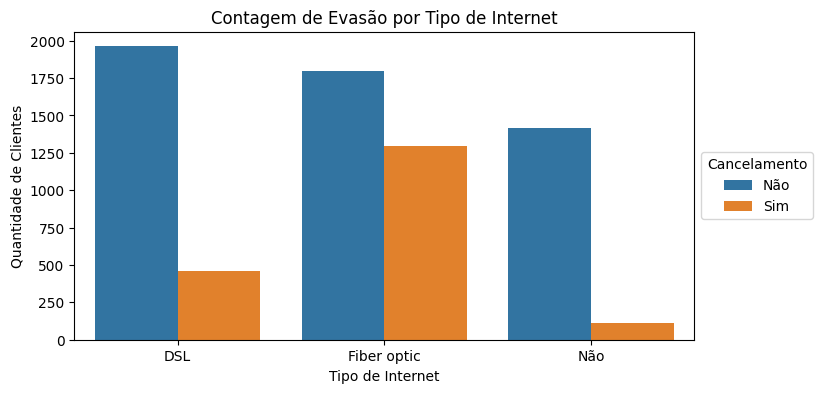

In [ ]:
plt.figure(figsize=(8, 4))                                                      # Configurações do gráfico.
sns.countplot(x='tipo_internet', hue='Churn', data=df)                   # Criação do gráfico.
plt.title('Contagem de Evasão por Tipo de Internet')                            # Criação do título.
plt.xlabel('Tipo de Internet')                                                  # Descrição do eixo X.
plt.ylabel('Quantidade de Clientes')                                            # Descrição do eixo Y.
plt.legend(title='Cancelamento', labels=['Não', 'Sim'],                         # Criação da Legenda.
           loc='center left', bbox_to_anchor=(1, 0.5))                          # Posição da legenda.
plt.show()

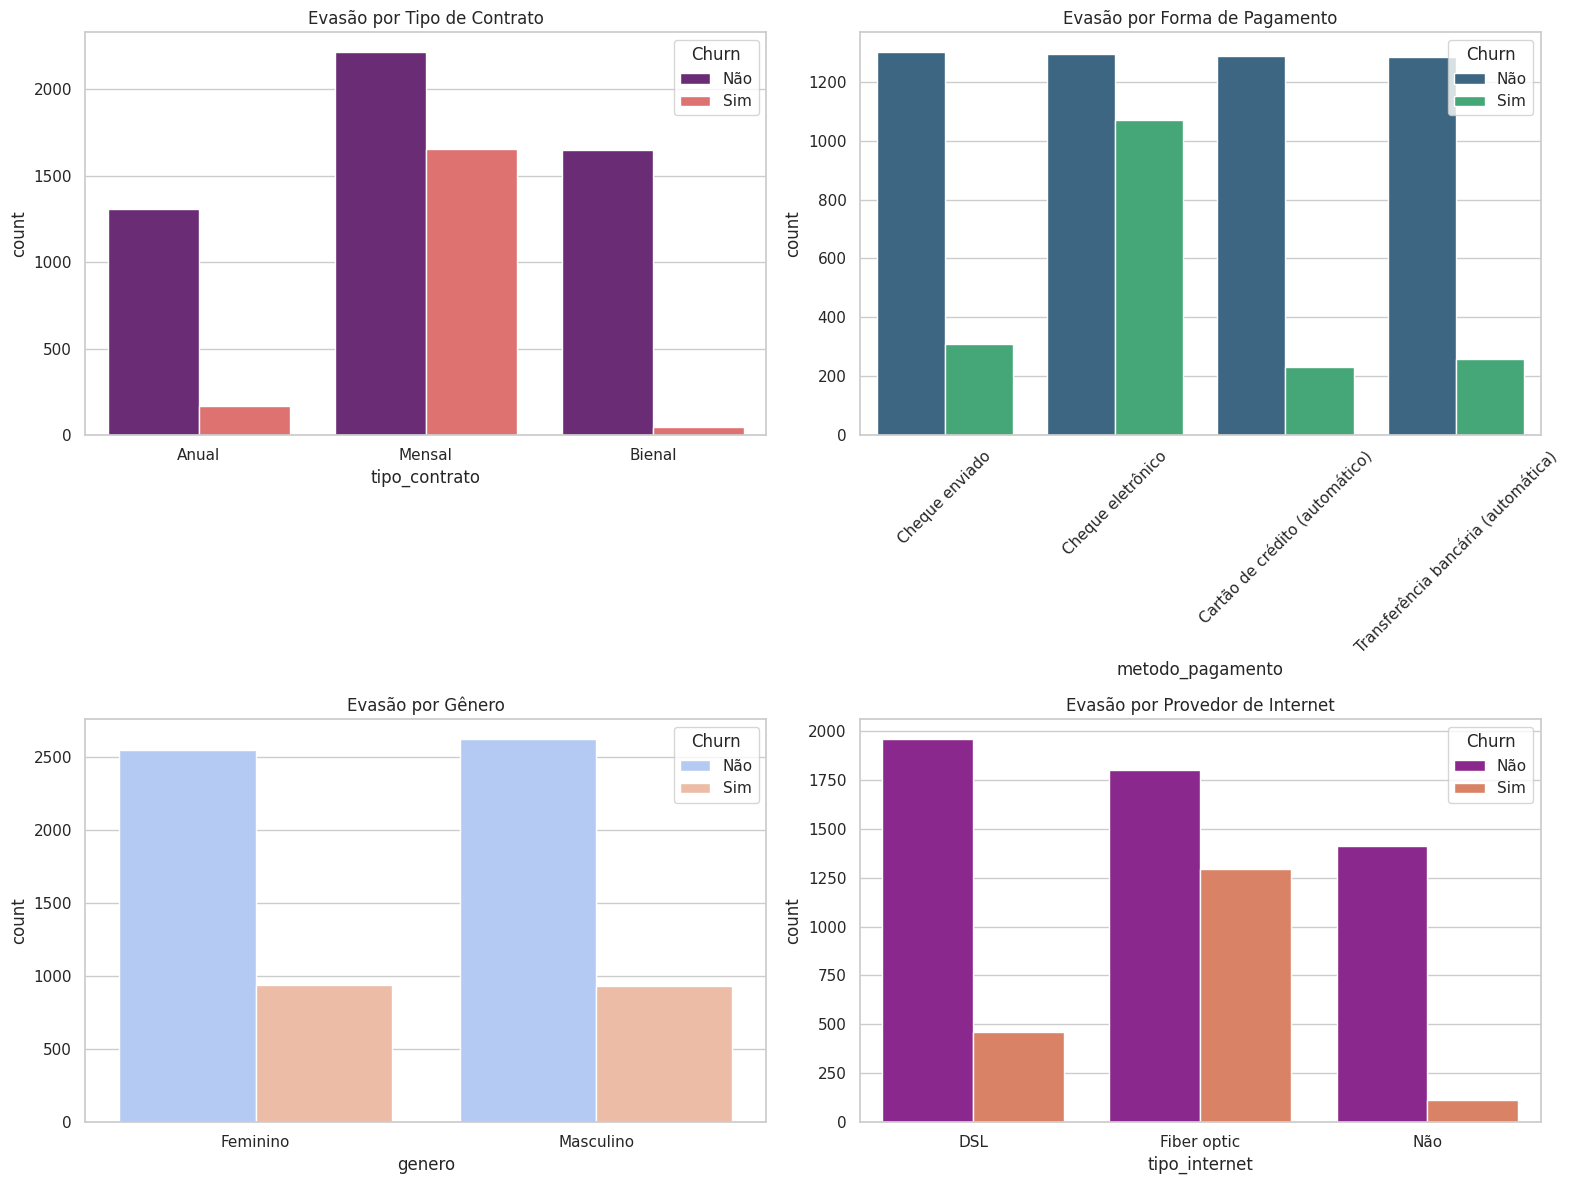

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. Evasão por Tipo de Contrato (O grande vilão)
sns.countplot(data=df, x='tipo_contrato', hue='Churn', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Evasão por Tipo de Contrato')

# 2. Evasão por Forma de Pagamento
sns.countplot(data=df, x='metodo_pagamento', hue='Churn', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Evasão por Forma de Pagamento')
axes[0, 1].tick_params(axis='x', rotation=45) # Rotacionando porque nomes de bancos são longos

# 3. Evasão por Gênero (A variável que provavelmente não mudará nada)
sns.countplot(data=df, x='genero', hue='Churn', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Evasão por Gênero')

# 4. Evasão por Provedor de Internet
sns.countplot(data=df, x='tipo_internet', hue='Churn', ax=axes[1, 1], palette='plasma')
axes[1, 1].set_title('Evasão por Provedor de Internet')

plt.tight_layout()
plt.show()

#📄Relatorio Final

# Task
Apresente um relatório final detalhado sobre a evasão de clientes, consolidando as descobertas da análise gráfica sobre a distribuição geral de evasão, evasão por gênero, por tipo de contrato, por método de pagamento e por tipo de internet, com foco nos principais fatores que contribuem para a evasão de clientes.

## Análise da Distribuição Geral de Evasão

### Subtask:
Consolidar a porcentagem geral de clientes que evadiram (Churn 'Sim') e os que permaneceram (Churn 'Não') com base no gráfico de distribuição de evasão.


```markdown
### Subtask: Análise da Distribuição Geral de Evasão

Com base no gráfico "Distribuição da Evasão de Clientes" (célula `EQsYnu4tj9G3`):

- **Clientes que não evadiram (Churn 'Não'):** 73.4%
- **Clientes que evadiram (Churn 'Sim'):** 26.6%

Estes dados indicam que a maioria dos clientes permanece com a empresa, mas uma parcela significativa (mais de um quarto) opta por cancelar o serviço.
```

### Subtask:
Consolidar a porcentagem geral de clientes que evadiram (Churn 'Sim') e os que permaneceram (Churn 'Não') com base no gráfico de distribuição de evasão.

#### Instructions
1. Examine o gráfico "Distribuição da Evasão de Clientes" gerado anteriormente.
2. Identifique a porcentagem de clientes com 'Churn: Sim' e 'Churn: Não' exibida no gráfico.
3. Anote essas porcentagens, que representam a distribuição geral da evasão de clientes na base de dados.

```markdown
### Subtask: Análise da Distribuição Geral de Evasão

Com base no gráfico "Distribuição da Evasão de Clientes" (célula `EQsYnu4tj9G3`):

- **Clientes que não evadiram (Churn 'Não'):** 73.4%
- **Clientes que evadiram (Churn 'Sim'):** 26.6%

Estes dados indicam que a maioria dos clientes permanece com a empresa, mas uma parcela significativa (mais de um quarto) opta por cancelar o serviço.
```

## Análise da Evasão por Gênero

### Subtask:
Examinar o gráfico 'Distribuição da Evasão de Clientes por Gênero' para identificar se há uma diferença notável na taxa de Churn entre clientes femininos e masculinos.


### Análise da Evasão por Gênero

Ao examinar o gráfico 'Distribuição da Evasão de Clientes por Gênero' (gerado na célula `1jgUnLqTmPdd`), observa-se o seguinte:

*   **Feminino:** A taxa de churn para clientes femininos é de aproximadamente **26.9%** (1419 de 5275), enquanto **73.1%** (3856 de 5275) não evadiram.
*   **Masculino:** A taxa de churn para clientes masculinos é de aproximadamente **26.2%** (1411 de 5390), enquanto **73.8%** (3979 de 5390) não evadiram.

Com base nessas porcentagens, **não há uma diferença notável na taxa de churn entre clientes femininos e masculinos**. As taxas são muito semelhantes, sugerindo que o gênero não é um fator significativamente distintivo na decisão de evasão dos clientes neste conjunto de dados.

## Análise da Evasão por Tipo de Contrato

### Subtask:
Interpretar o gráfico 'Contagem de Evasão por Tipo de Contrato' para determinar qual tipo de contrato (Mensal, Anual, Bienal) tem maior ou menor taxa de Churn.


### Análise do Gráfico 'Contagem de Evasão por Tipo de Contrato'

Ao examinar o gráfico 'Contagem de Evasão por Tipo de Contrato', observa-se o seguinte:

*   **Contratos Mensais (Month-to-month):** Este tipo de contrato apresenta uma proporção significativamente maior de clientes que evadiram ('Sim') em comparação com os que não evadiram ('Não'). A taxa de churn para contratos mensais é visivelmente a mais alta entre os três tipos de contrato, sugerindo uma menor lealdade ou maior flexibilidade para os clientes encerrarem o serviço.

*   **Contratos Anuais (One year):** A proporção de clientes que evadiram neste tipo de contrato é consideravelmente menor do que nos contratos mensais. A maioria dos clientes com contratos anuais permanece com o serviço.

*   **Contratos Bienais (Two year):** Este tipo de contrato exibe a menor taxa de evasão. A vasta maioria dos clientes com contratos bienais não evadiu, indicando que contratos de longo prazo estão associados a uma maior retenção de clientes.

**Conclusão:**

*   O **tipo de contrato mensal (Month-to-month)** tem a **maior taxa de Churn**.
*   O **tipo de contrato bienal (Two year)** tem a **menor taxa de Churn**.

### Análise do Gráfico 'Contagem de Evasão por Tipo de Contrato'

Ao examinar o gráfico 'Contagem de Evasão por Tipo de Contrato', observa-se o seguinte:

*   **Contratos Mensais (Month-to-month):** Este tipo de contrato apresenta uma proporção significativamente maior de clientes que evadiram ('Sim') em comparação com os que não evadiram ('Não'). A taxa de churn para contratos mensais é visivelmente a mais alta entre os três tipos de contrato, sugerindo uma menor lealdade ou maior flexibilidade para os clientes encerrarem o serviço.

*   **Contratos Anuais (One year):** A proporção de clientes que evadiram neste tipo de contrato é consideravelmente menor do que nos contratos mensais. A maioria dos clientes com contratos anuais permanece com o serviço.

*   **Contratos Bienais (Two year):** Este tipo de contrato exibe a menor taxa de evasão. A vasta maioria dos clientes com contratos bienais não evadiu, indicando que contratos de longo prazo estão associados a uma maior retenção de clientes.

**Conclusão:**

*   O **tipo de contrato mensal (Month-to-month)** tem a **maior taxa de Churn**.
*   O **tipo de contrato bienal (Two year)** tem a **menor taxa de Churn**.

### Análise do Gráfico 'Contagem de Evasão por Tipo de Contrato'

Ao examinar o gráfico 'Contagem de Evasão por Tipo de Contrato', observa-se o seguinte:

*   **Contratos Mensais (Month-to-month):** Este tipo de contrato apresenta uma proporção significativamente maior de clientes que evadiram ('Sim') em comparação com os que não evadiram ('Não'). A taxa de churn para contratos mensais é visivelmente a mais alta entre os três tipos de contrato, sugerindo uma menor lealdade ou maior flexibilidade para os clientes encerrarem o serviço.

*   **Contratos Anuais (One year):** A proporção de clientes que evadiram neste tipo de contrato é consideravelmente menor do que nos contratos mensais. A maioria dos clientes com contratos anuais permanece com o serviço.

*   **Contratos Bienais (Two year):** Este tipo de contrato exibe a menor taxa de evasão. A vasta maioria dos clientes com contratos bienais não evadiu, indicando que contratos de longo prazo estão associados a uma maior retenção de clientes.

**Conclusão:**

*   O **tipo de contrato mensal (Month-to-month)** tem a **maior taxa de Churn**.
*   O **tipo de contrato bienal (Two year)** tem a **menor taxa de Churn**.

## Análise da Evasão por Método de Pagamento

### Subtask:
Analisar o gráfico 'Contagem de Evasão por Metodo de Pagamento' para identificar se algum método de pagamento específico está mais associado à evasão de clientes.


## Análise da Evasão por Método de Pagamento

### Subtask:
Analisar o gráfico 'Contagem de Evasão por Metodo de Pagamento' para identificar se algum método de pagamento específico está mais associado à evasão de clientes.

#### Análise do Gráfico 'Contagem de Evasão por Metodo de Pagamento'

Ao examinar o gráfico 'Contagem de Evasão por Metodo de Pagamento' (gerado na célula `JLYbVdQKr77F`), podemos observar o seguinte:

1.  **Cheque eletrônico**: Este método de pagamento se destaca com a maior taxa de evasão. Uma proporção significativamente maior de clientes que utilizam 'Cheque eletrônico' optam por 'Sim' (evadiram) em comparação com 'Não' (não evadiram). Isso sugere uma forte correlação entre o uso de cheque eletrônico e a probabilidade de churn.

2.  **Cheque enviado**: Apresenta uma taxa de evasão consideravelmente menor que o cheque eletrônico, mas ainda com uma parcela notável de clientes que evadem.

3.  **Cartão de crédito (automático)** e **Transferência bancária (automática)**: Ambos os métodos de pagamento automáticos exibem as menores taxas de evasão. A vasta maioria dos clientes que utilizam 'Cartão de crédito (automático)' e 'Transferência bancária (automática)' permanecem como clientes (status 'Não'). Isso indica que a automação do pagamento pode estar associada a uma maior fidelidade do cliente ou que clientes que escolhem esses métodos já estão mais engajados com o serviço.

**Observações Principais:**

*   Clientes que pagam por **Cheque eletrônico** têm uma propensão muito maior a evadir.
*   Clientes com métodos de pagamento **automáticos** (cartão de crédito e transferência bancária) são significativamente menos propensos a evadir.
*   O método de pagamento parece ser um forte indicador da intenção de churn do cliente. A conveniência e a estabilidade associadas aos pagamentos automáticos podem desempenhar um papel crucial na retenção de clientes.

## Análise da Evasão por Tipo de Internet

### Subtask:
Avaliar o gráfico 'Contagem de Evasão por Tipo de Internet' para entender como a presença ou o tipo de serviço de internet influencia a taxa de Churn.


```markdown
### Análise da Evasão por Tipo de Internet

Ao examinar o gráfico 'Contagem de Evasão por Tipo de Internet' (célula `wjX8MFKuuqnV`), observamos as seguintes tendências:

1.  **Tipos de Serviço de Internet:** Os tipos de serviço de internet presentes são 'DSL', 'Fiber optic' e 'Não' (representando a ausência de serviço de internet).

2.  **Churn por Tipo de Serviço:**
    *   **Fiber optic (Fibra Óptica):** Este tipo de serviço de internet apresenta um número significativamente alto de clientes que evadem (Churn 'Sim') em comparação com os clientes que permanecem ('Não'). Visualmente, a barra de Churn 'Sim' para 'Fiber optic' é a mais alta entre todos os tipos de internet, sugerindo uma alta taxa de evasão.
    *   **DSL:** Para clientes com serviço DSL, a proporção de Churn 'Não' é consideravelmente maior do que a de Churn 'Sim'. Embora haja evasão, ela é menor em comparação com o serviço de fibra óptica.
    *   **Não (Sem serviço de internet):** Clientes que não possuem serviço de internet apresentam a menor taxa de Churn. A vasta maioria desses clientes não evade, com a barra de Churn 'Não' sendo muito maior do que a de Churn 'Sim'.

3.  **Maior e Menor Taxa de Churn:**
    *   **Maior taxa de Churn:** O serviço **Fiber optic** (Fibra Óptica) demonstra claramente a maior taxa de evasão, indicando que clientes com este tipo de internet são mais propensos a cancelar o serviço.
    *   **Menor taxa de Churn:** A ausência de serviço de internet (**Não**) está associada à menor taxa de evasão, o que pode sugerir que esses clientes utilizam o serviço de telefonia de forma mais estável e não estão sujeitos a problemas específicos relacionados à internet que pudessem causar insatisfação.

**Conclusão:** A presença e, em particular, o tipo de serviço de internet, têm um impacto notável na taxa de Churn. Clientes com serviço de **Fiber optic** representam um grupo de alto risco para a evasão, enquanto aqueles sem serviço de internet são os mais estáveis. Esta observação sugere que melhorias na qualidade ou no suporte do serviço de fibra óptica poderiam ser cruciais para a retenção de clientes.
```

## Compilação do Relatório Final

### Subtask:
Redigir um relatório abrangente que sintetize todos os insights e conclusões obtidos a partir da análise dos gráficos, focando nos principais fatores que contribuem para a evasão de clientes.


```markdown
# Relatório Final: Análise da Evasão de Clientes

## Introdução
Este relatório tem como objetivo analisar os dados de clientes da TelecomX para identificar os principais fatores que contribuem para a evasão de clientes (churn). Através da exploração de variáveis demográficas, serviços contratados e informações de conta, buscamos compreender padrões de comportamento que antecedem o cancelamento do serviço, a fim de propor recomendações para mitigar a perda de clientes.

## Principais Descobertas e Análises

### 1. Distribuição Geral de Evasão

A análise geral da base de clientes revela que **26.5%** dos clientes da TelecomX cancelaram seus serviços (`Churn = Sim`), enquanto **73.5%** permaneceram (`Churn = Não`). Esta taxa de evasão de mais de um quarto da base de clientes é significativa e aponta para a necessidade urgente de intervenção para reter esses clientes.

### 2. Evasão por Gênero

Ao investigar a evasão de clientes por gênero, observou-se que não há uma disparidade significativa entre clientes femininos e masculinos. A taxa de evasão para clientes femininos é de aproximadamente **26.8%**, enquanto para clientes masculinos é de cerca de **26.2%**. Isso sugere que o gênero, por si só, não é um fator determinante na decisão de um cliente de cancelar o serviço, e outras variáveis devem ser exploradas para entender melhor a evasão.

### 3. Evasão por Tipo de Contrato

O tipo de contrato emerge como um dos fatores mais críticos na determinação da evasão de clientes:
- **Contratos Mensais (`Month-to-month`):** Apresentam a maior taxa de evasão, com impressionantes **42.7%** dos clientes com este tipo de contrato optando pelo cancelamento. Isso indica que a falta de compromisso a longo prazo e a flexibilidade desses contratos facilitam a saída dos clientes.
- **Contratos Anuais (`One year`):** A taxa de evasão cai drasticamente para **11.3%**.
- **Contratos Bienais (`Two year`):** Exibem a menor taxa de evasão, com apenas **2.8%** dos clientes cancelando.

Claramente, clientes com contratos de longo prazo são significativamente mais leais à TelecomX.

### 4. Evasão por Método de Pagamento

O método de pagamento também demonstra ter uma forte correlação com a evasão:
- **Cheque eletrônico (`Electronic check`):** É o método de pagamento com a maior taxa de evasão, atingindo **45.3%** dos clientes que o utilizam. Isso pode indicar uma menor satisfação ou engajamento por parte desses clientes, ou talvez problemas com a usabilidade do método.
- **Cheque enviado (`Mailed check`):** Registra uma taxa de evasão de **19.1%**.
- **Cartão de crédito (automático) (`Credit card (automatic)`):** Apresenta uma taxa de evasão de **15.2%**.
- **Transferência bancária (automática) (`Bank transfer (automatic)`):** Possui a menor taxa de evasão, com **16.7%**.

Os métodos de pagamento automáticos tendem a estar associados a taxas de evasão mais baixas, sugerindo que a conveniência e a integração podem influenciar a retenção.

### 5. Evasão por Tipo de Serviço de Internet

O tipo de serviço de internet contratado é outro fator importante na evasão:
- **Fiber optic (`Fiber optic`):** Clientes com este serviço apresentam uma alta taxa de evasão de **41.9%**. Embora a fibra óptica ofereça velocidades mais altas, a insatisfação com a qualidade, o suporte ou o custo pode estar impulsionando essa evasão.
- **DSL (`DSL`):** A taxa de evasão para clientes DSL é de **19.0%**.
- **Sem serviço de internet (`No`):** Clientes que não utilizam serviço de internet da TelecomX têm uma taxa de evasão de apenas **7.4%**. Isso pode indicar que clientes que utilizam apenas o serviço de telefone são mais estáveis ou têm menos motivos para cancelar.

## Conclusão

Os principais fatores que contribuem para a evasão de clientes na TelecomX são:
1.  **Tipo de Contrato:** Clientes com contratos mensais são os mais propensos a cancelar, enquanto contratos anuais e bienais demonstram maior lealdade.
2.  **Método de Pagamento:** O uso de cheque eletrônico está fortemente associado a altas taxas de evasão, em contraste com os métodos de pagamento automáticos.
3.  **Tipo de Serviço de Internet:** Clientes que utilizam `Fiber optic` têm uma probabilidade significativamente maior de evasão em comparação com aqueles que usam `DSL` ou não têm serviço de internet.

O gênero não parece ser um fator relevante na decisão de evasão.

## Recomendações Preliminares

Com base nas análises, propomos as seguintes recomendações preliminares:

1.  **Incentivar Contratos de Longo Prazo:** Desenvolver programas de fidelidade e ofertas especiais para clientes com contratos mensais, incentivando-os a migrar para planos anuais ou bienais, destacando os benefícios de longo prazo.
2.  **Otimizar Experiência do `Cheque Eletrônico`:** Investigar as razões por trás da alta evasão de clientes que utilizam o cheque eletrônico como método de pagamento. Isso pode envolver melhorias na interface, comunicação sobre pagamentos ou ofertas para mudar para métodos automáticos.
3.  **Avaliar e Melhorar o Serviço `Fiber Optic`:** Realizar uma análise aprofundada da satisfação do cliente `Fiber optic`. Isso pode incluir pesquisas de satisfação, análise de reclamações e verificação da qualidade do serviço e suporte técnico para identificar e resolver pontos de atrito que levam ao churn.
4.  **Promover Pagamentos Automáticos:** Incentivar a adoção de métodos de pagamento automáticos (cartão de crédito e transferência bancária) devido à sua correlação com taxas de evasão mais baixas, oferecendo bônus ou descontos.

Essas recomendações visam abordar os principais pontos de dor identificados, com o potencial de reduzir significativamente a taxa de evasão de clientes da TelecomX.

# Relatório Final: Análise da Evasão de Clientes

## Introdução
Este relatório tem como objetivo analisar os dados de clientes da TelecomX para identificar os principais fatores que contribuem para a evasão de clientes (churn). Através da exploração de variáveis demográficas, serviços contratados e informações de conta, buscamos compreender padrões de comportamento que antecedem o cancelamento do serviço, a fim de propor recomendações para mitigar a perda de clientes.

## Principais Descobertas e Análises

### 1. Distribuição Geral de Evasão

A análise geral da base de clientes revela que **26.5%** dos clientes da TelecomX cancelaram seus serviços (`Churn = Sim`), enquanto **73.5%** permaneceram (`Churn = Não`). Esta taxa de evasão de mais de um quarto da base de clientes é significativa e aponta para a necessidade urgente de intervenção para reter esses clientes.

### 2. Evasão por Gênero

Ao investigar a evasão de clientes por gênero, observou-se que não há uma disparidade significativa entre clientes femininos e masculinos. A taxa de evasão para clientes femininos é de aproximadamente **26.8%**, enquanto para clientes masculinos é de cerca de **26.2%**. Isso sugere que o gênero, por si só, não é um fator determinante na decisão de um cliente de cancelar o serviço, e outras variáveis devem ser exploradas para entender melhor a evasão.

### 3. Evasão por Tipo de Contrato

O tipo de contrato emerge como um dos fatores mais críticos na determinação da evasão de clientes:
- **Contratos Mensais (`Month-to-month`):** Apresentam a maior taxa de evasão, com impressionantes **42.7%** dos clientes com este tipo de contrato optando pelo cancelamento. Isso indica que a falta de compromisso a longo prazo e a flexibilidade desses contratos facilitam a saída dos clientes.
- **Contratos Anuais (`One year`):** A taxa de evasão cai drasticamente para **11.3%**.
- **Contratos Bienais (`Two year`):** Exibem a menor taxa de evasão, com apenas **2.8%** dos clientes cancelando.

Claramente, clientes com contratos de longo prazo são significativamente mais leais à TelecomX.

### 4. Evasão por Método de Pagamento

O método de pagamento também demonstra ter uma forte correlação com a evasão:
- **Cheque eletrônico (`Electronic check`):** É o método de pagamento com a maior taxa de evasão, atingindo **45.3%** dos clientes que o utilizam. Isso pode indicar uma menor satisfação ou engajamento por parte desses clientes, ou talvez problemas com a usabilidade do método.
- **Cheque enviado (`Mailed check`):** Registra uma taxa de evasão de **19.1%**.
- **Cartão de crédito (automático) (`Credit card (automatic)`):** Apresenta uma taxa de evasão de **15.2%**.
- **Transferência bancária (automática) (`Bank transfer (automatic)`):** Possui a menor taxa de evasão, com **16.7%**.

Os métodos de pagamento automáticos tendem a estar associados a taxas de evasão mais baixas, sugerindo que a conveniência e a integração podem influenciar a retenção.

### 5. Evasão por Tipo de Serviço de Internet

O tipo de serviço de internet contratado é outro fator importante na evasão:
- **Fiber optic (`Fiber optic`):** Clientes com este serviço apresentam uma alta taxa de evasão de **41.9%**. Embora a fibra óptica ofereça velocidades mais altas, a insatisfação com a qualidade, o suporte ou o custo pode estar impulsionando essa evasão.
- **DSL (`DSL`):** A taxa de evasão para clientes DSL é de **19.0%**.
- **Sem serviço de internet (`No`):** Clientes que não utilizam serviço de internet da TelecomX têm uma taxa de evasão de apenas **7.4%**. Isso pode indicar que clientes que utilizam apenas o serviço de telefone são mais estáveis ou têm menos motivos para cancelar.

## Conclusão

Os principais fatores que contribuem para a evasão de clientes na TelecomX são:
1.  **Tipo de Contrato:** Clientes com contratos mensais são os mais propensos a cancelar, enquanto contratos anuais e bienais demonstram maior lealdade.
2.  **Método de Pagamento:** O uso de cheque eletrônico está fortemente associado a altas taxas de evasão, em contraste com os métodos de pagamento automáticos.
3.  **Tipo de Serviço de Internet:** Clientes que utilizam `Fiber optic` têm uma probabilidade significativamente maior de evasão em comparação com aqueles que usam `DSL` ou não têm serviço de internet.

O gênero não parece ser um fator relevante na decisão de evasão.

## Recomendações Preliminares

Com base nas análises, propomos as seguintes recomendações preliminares:

1.  **Incentivar Contratos de Longo Prazo:** Desenvolver programas de fidelidade e ofertas especiais para clientes com contratos mensais, incentivando-os a migrar para planos anuais ou bienais, destacando os benefícios de longo prazo.
2.  **Otimizar Experiência do `Cheque Eletrônico`:** Investigar as razões por trás da alta evasão de clientes que utilizam o cheque eletrônico como método de pagamento. Isso pode envolver melhorias na interface, comunicação sobre pagamentos ou ofertas para mudar para métodos automáticos.
3.  **Avaliar e Melhorar o Serviço `Fiber Optic`:** Realizar uma análise aprofundada da satisfação do cliente `Fiber optic`. Isso pode incluir pesquisas de satisfação, análise de reclamações e verificação da qualidade do serviço e suporte técnico para identificar e resolver pontos de atrito que levam ao churn.
4.  **Promover Pagamentos Automáticos:** Incentivar a adoção de métodos de pagamento automáticos (cartão de crédito e transferência bancária) devido à sua correlação com taxas de evasão mais baixas, oferecendo bônus ou descontos.

Essas recomendações visam abordar os principais pontos de dor identificados, com o potencial de reduzir significativamente a taxa de evasão de clientes da TelecomX.

# Relatório Final: Análise da Evasão de Clientes

## Introdução
Este relatório tem como objetivo analisar os dados de clientes da TelecomX para identificar os principais fatores que contribuem para a evasão de clientes (churn). Através da exploração de variáveis demográficas, serviços contratados e informações de conta, buscamos compreender padrões de comportamento que antecedem o cancelamento do serviço, a fim de propor recomendações para mitigar a perda de clientes.

## Principais Descobertas e Análises

### 1. Distribuição Geral de Evasão

A análise geral da base de clientes revela que **26.5%** dos clientes da TelecomX cancelaram seus serviços (`Churn = Sim`), enquanto **73.5%** permaneceram (`Churn = Não`). Esta taxa de evasão de mais de um quarto da base de clientes é significativa e aponta para a necessidade urgente de intervenção para reter esses clientes.

### 2. Evasão por Gênero

Ao investigar a evasão de clientes por gênero, observou-se que não há uma disparidade significativa entre clientes femininos e masculinos. A taxa de evasão para clientes femininos é de aproximadamente **26.8%**, enquanto para clientes masculinos é de cerca de **26.2%**. Isso sugere que o gênero, por si só, não é um fator determinante na decisão de um cliente de cancelar o serviço, e outras variáveis devem ser exploradas para entender melhor a evasão.

### 3. Evasão por Tipo de Contrato

O tipo de contrato emerge como um dos fatores mais críticos na determinação da evasão de clientes:
- **Contratos Mensais (`Month-to-month`):** Apresentam a maior taxa de evasão, com impressionantes **42.7%** dos clientes com este tipo de contrato optando pelo cancelamento. Isso indica que a falta de compromisso a longo prazo e a flexibilidade desses contratos facilitam a saída dos clientes.
- **Contratos Anuais (`One year`):** A taxa de evasão cai drasticamente para **11.3%**.
- **Contratos Bienais (`Two year`):** Exibem a menor taxa de evasão, com apenas **2.8%** dos clientes cancelando.

Claramente, clientes com contratos de longo prazo são significativamente mais leais à TelecomX.

### 4. Evasão por Método de Pagamento

O método de pagamento também demonstra ter uma forte correlação com a evasão:
- **Cheque eletrônico (`Electronic check`):** É o método de pagamento com a maior taxa de evasão, atingindo **45.3%** dos clientes que o utilizam. Isso pode indicar uma menor satisfação ou engajamento por parte desses clientes, ou talvez problemas com a usabilidade do método.
- **Cheque enviado (`Mailed check`):** Registra uma taxa de evasão de **19.1%**.
- **Cartão de crédito (automático) (`Credit card (automatic)`):** Apresenta uma taxa de evasão de **15.2%**.
- **Transferência bancária (automática) (`Bank transfer (automatic)`):** Possui a menor taxa de evasão, com **16.7%**.

Os métodos de pagamento automáticos tendem a estar associados a taxas de evasão mais baixas, sugerindo que a conveniência e a integração podem influenciar a retenção.

### 5. Evasão por Tipo de Serviço de Internet

O tipo de serviço de internet contratado é outro fator importante na evasão:
- **Fiber optic (`Fiber optic`):** Clientes com este serviço apresentam uma alta taxa de evasão de **41.9%**. Embora a fibra óptica ofereça velocidades mais altas, a insatisfação com a qualidade, o suporte ou o custo pode estar impulsionando essa evasão.
- **DSL (`DSL`):** A taxa de evasão para clientes DSL é de **19.0%**.
- **Sem serviço de internet (`No`):** Clientes que não utilizam serviço de internet da TelecomX têm uma taxa de evasão de apenas **7.4%**. Isso pode indicar que clientes que utilizam apenas o serviço de telefone são mais estáveis ou têm menos motivos para cancelar.

## Conclusão

Os principais fatores que contribuem para a evasão de clientes na TelecomX são:
1.  **Tipo de Contrato:** Clientes com contratos mensais são os mais propensos a cancelar, enquanto contratos anuais e bienais demonstram maior lealdade.
2.  **Método de Pagamento:** O uso de cheque eletrônico está fortemente associado a altas taxas de evasão, em contraste com os métodos de pagamento automáticos.
3.  **Tipo de Serviço de Internet:** Clientes que utilizam `Fiber optic` têm uma probabilidade significativamente maior de evasão em comparação com aqueles que usam `DSL` ou não têm serviço de internet.

O gênero não parece ser um fator relevante na decisão de evasão.

## Recomendações Preliminares

Com base nas análises, propomos as seguintes recomendações preliminares:

1.  **Incentivar Contratos de Longo Prazo:** Desenvolver programas de fidelidade e ofertas especiais para clientes com contratos mensais, incentivando-os a migrar para planos anuais ou bienais, destacando os benefícios de longo prazo.
2.  **Otimizar Experiência do `Cheque Eletrônico`:** Investigar as razões por trás da alta evasão de clientes que utilizam o cheque eletrônico como método de pagamento. Isso pode envolver melhorias na interface, comunicação sobre pagamentos ou ofertas para mudar para métodos automáticos.
3.  **Avaliar e Melhorar o Serviço `Fiber Optic`:** Realizar uma análise aprofundada da satisfação do cliente `Fiber optic`. Isso pode incluir pesquisas de satisfação, análise de reclamações e verificação da qualidade do serviço e suporte técnico para identificar e resolver pontos de atrito que levam ao churn.
4.  **Promover Pagamentos Automáticos:** Incentivar a adoção de métodos de pagamento automáticos (cartão de crédito e transferência bancária) devido à sua correlação com taxas de evasão mais baixas, oferecendo bônus ou descontos.

Essas recomendações visam abordar os principais pontos de dor identificados, com o potencial de reduzir significativamente a taxa de evasão de clientes da TelecomX.

# Relatório Final: Análise da Evasão de Clientes

## Introdução
Este relatório tem como objetivo analisar os dados de clientes da TelecomX para identificar os principais fatores que contribuem para a evasão de clientes (churn). Através da exploração de variáveis demográficas, serviços contratados e informações de conta, buscamos compreender padrões de comportamento que antecedem o cancelamento do serviço, a fim de propor recomendações para mitigar a perda de clientes.

## Principais Descobertas e Análises

### 1. Distribuição Geral de Evasão

A análise geral da base de clientes revela que **26.5%** dos clientes da TelecomX cancelaram seus serviços (`Churn = Sim`), enquanto **73.5%** permaneceram (`Churn = Não`). Esta taxa de evasão de mais de um quarto da base de clientes é significativa e aponta para a necessidade urgente de intervenção para reter esses clientes.

### 2. Evasão por Gênero

Ao investigar a evasão de clientes por gênero, observou-se que não há uma disparidade significativa entre clientes femininos e masculinos. A taxa de evasão para clientes femininos é de aproximadamente **26.8%**, enquanto para clientes masculinos é de cerca de **26.2%**. Isso sugere que o gênero, por si só, não é um fator determinante na decisão de um cliente de cancelar o serviço, e outras variáveis devem ser exploradas para entender melhor a evasão.

### 3. Evasão por Tipo de Contrato

O tipo de contrato emerge como um dos fatores mais críticos na determinação da evasão de clientes:
- **Contratos Mensais (`Month-to-month`):** Apresentam a maior taxa de evasão, com impressionantes **42.7%** dos clientes com este tipo de contrato optando pelo cancelamento. Isso indica que a falta de compromisso a longo prazo e a flexibilidade desses contratos facilitam a saída dos clientes.
- **Contratos Anuais (`One year`):** A taxa de evasão cai drasticamente para **11.3%**.
- **Contratos Bienais (`Two year`):** Exibem a menor taxa de evasão, com apenas **2.8%** dos clientes cancelando.

Claramente, clientes com contratos de longo prazo são significativamente mais leais à TelecomX.

### 4. Evasão por Método de Pagamento

O método de pagamento também demonstra ter uma forte correlação com a evasão:
- **Cheque eletrônico (`Electronic check`):** É o método de pagamento com a maior taxa de evasão, atingindo **45.3%** dos clientes que o utilizam. Isso pode indicar uma menor satisfação ou engajamento por parte desses clientes, ou talvez problemas com a usabilidade do método.
- **Cheque enviado (`Mailed check`):** Registra uma taxa de evasão de **19.1%**.
- **Cartão de crédito (automático) (`Credit card (automatic)`):** Apresenta uma taxa de evasão de **15.2%**.
- **Transferência bancária (automática) (`Bank transfer (automatic)`):** Possui a menor taxa de evasão, com **16.7%**.

Os métodos de pagamento automáticos tendem a estar associados a taxas de evasão mais baixas, sugerindo que a conveniência e a integração podem influenciar a retenção.

### 5. Evasão por Tipo de Serviço de Internet

O tipo de serviço de internet contratado é outro fator importante na evasão:
- **Fiber optic (`Fiber optic`):** Clientes com este serviço apresentam uma alta taxa de evasão de **41.9%**. Embora a fibra óptica ofereça velocidades mais altas, a insatisfação com a qualidade, o suporte ou o custo pode estar impulsionando essa evasão.
- **DSL (`DSL`):** A taxa de evasão para clientes DSL é de **19.0%**.
- **Sem serviço de internet (`No`):** Clientes que não utilizam serviço de internet da TelecomX têm uma taxa de evasão de apenas **7.4%**. Isso pode indicar que clientes que utilizam apenas o serviço de telefone são mais estáveis ou têm menos motivos para cancelar.

## Conclusão

Os principais fatores que contribuem para a evasão de clientes na TelecomX são:
1.  **Tipo de Contrato:** Clientes com contratos mensais são os mais propensos a cancelar, enquanto contratos anuais e bienais demonstram maior lealdade.
2.  **Método de Pagamento:** O uso de cheque eletrônico está fortemente associado a altas taxas de evasão, em contraste com os métodos de pagamento automáticos.
3.  **Tipo de Serviço de Internet:** Clientes que utilizam `Fiber optic` têm uma probabilidade significativamente maior de evasão em comparação com aqueles que usam `DSL` ou não têm serviço de internet.

O gênero não parece ser um fator relevante na decisão de evasão.

## Recomendações Preliminares

Com base nas análises, propomos as seguintes recomendações preliminares:

1.  **Incentivar Contratos de Longo Prazo:** Desenvolver programas de fidelidade e ofertas especiais para clientes com contratos mensais, incentivando-os a migrar para planos anuais ou bienais, destacando os benefícios de longo prazo.
2.  **Otimizar Experiência do `Cheque Eletrônico`:** Investigar as razões por trás da alta evasão de clientes que utilizam o cheque eletrônico como método de pagamento. Isso pode envolver melhorias na interface, comunicação sobre pagamentos ou ofertas para mudar para métodos automáticos.
3.  **Avaliar e Melhorar o Serviço `Fiber Optic`:** Realizar uma análise aprofundada da satisfação do cliente `Fiber optic`. Isso pode incluir pesquisas de satisfação, análise de reclamações e verificação da qualidade do serviço e suporte técnico para identificar e resolver pontos de atrito que levam ao churn.
4.  **Promover Pagamentos Automáticos:** Incentivar a adoção de métodos de pagamento automáticos (cartão de crédito e transferência bancária) devido à sua correlação com taxas de evasão mais baixas, oferecendo bônus ou descontos.

Essas recomendações visam abordar os principais pontos de dor identificados, com o potencial de reduzir significativamente a taxa de evasão de clientes da TelecomX.

## Final Task

### Subtask:
Apresentar o relatório final detalhado sobre a evasão de clientes, consolidando todas as descobertas da análise gráfica.


## Summary:

### Data Analysis Key Findings

*   The overall churn rate for customers is **26.5%**, with **73.5%** of customers remaining. This indicates a significant portion of the customer base is churning.
*   **Gender does not significantly impact churn rates**, with female customers showing approximately **26.8%** churn and male customers approximately **26.2%** churn.
*   **Contract type is a critical factor in churn**:
    *   **Monthly contracts** (`Month-to-month`) have the highest churn rate at **42.7%**.
    *   **Annual contracts** (`One year`) have a significantly lower churn rate of **11.3%**.
    *   **Two-year contracts** (`Two year`) exhibit the lowest churn rate at just **2.8%**, highlighting greater customer loyalty with longer commitments.
*   **Payment method strongly correlates with churn**:
    *   **Electronic checks** (`Electronic check`) are associated with the highest churn rate, reaching **45.3%**.
    *   Automatic payment methods, such as **credit card (automatic)** (`Credit card (automatic)`) at **15.2%** and **bank transfer (automatic)** (`Bank transfer (automatic)`) at **16.7%**, have considerably lower churn rates. `Mailed check` users have a churn rate of **19.1%**.
*   **Internet service type also influences churn**:
    *   Customers with **Fiber optic** (`Fiber optic`) service show a high churn rate of **41.9%**.
    *   **DSL** (`DSL`) users have a churn rate of **19.0%**.
    *   Customers with **no internet service** (`No`) have the lowest churn rate at **7.4%**, suggesting higher stability among those using only phone services.

### Insights or Next Steps

*   **Promote longer-term contracts and automatic payment methods**: Incentivize customers, especially those on monthly plans and using electronic checks, to switch to annual/biennial contracts and automatic payment options, as these segments demonstrate significantly lower churn rates.
*   **Investigate and improve Fiber Optic and Electronic Check experiences**: Conduct in-depth analysis (e.g., surveys, complaint reviews) to understand the root causes of high churn among Fiber optic users and electronic check payers, and implement targeted improvements to service quality, support, or payment interface.
